# Phase 1: Data Audit & Span Universe

Loads and validates all source tables, sentence-tokenizes each AI response to
build the span universe, then constructs the Stage A panel (parent × sentence).

All key DataFrames are pickled to `traces/` for handoff to downstream notebooks.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'pandas', 'numpy', 'nltk', 'scipy'], check=False)
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('Dependencies ready.')

Dependencies ready.


In [2]:
import csv, glob, json, os, pickle, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from nltk.tokenize import sent_tokenize

SEED = 20260506
np.random.seed(SEED)

# ── Paths ──────────────────────────────────────────────────────────────────
_nb_dir = os.path.abspath('.')
REPO_ROOT = os.path.abspath(os.path.join(_nb_dir, '..', '..'))
_export_dirs = sorted(glob.glob(os.path.join(REPO_ROOT, 'data-exports', '*', 'moderation_sessions_export_*.csv')))
if not _export_dirs:
    raise FileNotFoundError('No moderation_sessions_export_*.csv found.')
DATA_DIR = os.path.dirname(_export_dirs[-1])
EXPORT_TS = _export_dirs[-1].split('_export_')[1].replace('.csv', '')
TRACES_DIR = os.path.join(_nb_dir, 'traces')
os.makedirs(TRACES_DIR, exist_ok=True)

print(f'DATA_DIR:  {DATA_DIR}')
print(f'TIMESTAMP: {EXPORT_TS}')
print(f'TRACES:    {TRACES_DIR}')

DATA_DIR:  /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260412_183830
TIMESTAMP: 20260412_183830
TRACES:    /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/stat_analysis/pilot_prediction/traces


## 1.1  Load and validate source tables

In [3]:
def _load(prefix):
    path = os.path.join(DATA_DIR, f'{prefix}_{EXPORT_TS}.csv')
    df = pd.read_csv(path)
    print(f'  {prefix}: {len(df):,} rows, {len(df.columns)} cols')
    return df

moderation_df = _load('moderation_sessions_export')
selections_df = _load('selections_export')
df_sel = pd.read_csv(os.path.join(DATA_DIR, 'highlight_analysis_output', 'df_sel.csv'))
print(f'  df_sel (master highlights): {len(df_sel):,} rows')

  moderation_sessions_export: 101 rows, 38 cols
  selections_export: 253 rows, 20 cols
  df_sel (master highlights): 267 rows


In [4]:
# ── Filter moderation_sessions to final approved sessions ─────────────────
mod = moderation_df.copy()
mod['is_final_version'] = mod['is_final_version'].astype(str).str.strip().str.lower()
mod = mod[mod['is_final_version'].isin(['true', '1'])].copy()
mod = mod[mod['prolific_pid'].notna() & (mod['prolific_pid'] != '')].copy()
if 'is_attention_check' in mod.columns:
    mod = mod[mod['is_attention_check'] != 1].copy()
# Keep only parents present in df_sel
approved_parent_ids = set(df_sel['parent_id'].unique())
mod = mod[mod['user_id'].isin(approved_parent_ids)].copy()
print(f'Filtered sessions: {len(mod)} (parents: {mod["user_id"].nunique()}, scenarios: {mod["scenario_id"].nunique()})')

Filtered sessions: 83 (parents: 20, scenarios: 45)


In [5]:
# ── Data structure note ───────────────────────────────────────────────────
# df_sel grain is (selection_id × concern_item_id) — neither column is unique
# on its own. One concern_item can link to multiple selections (shared rationale)
# and one selection can link to multiple concern_items (multiple rationale blocks).
# Compound key (selection_id, concern_item_id) is unique across all 267 rows.
# 267 rows = 200 unique selections, 186 unique concern_items.

n_rows             = len(df_sel)
n_unique_sel       = df_sel['selection_id'].nunique()
n_unique_ci        = df_sel['concern_item_id'].nunique()
n_unique_compound  = df_sel[['selection_id', 'concern_item_id']].drop_duplicates().shape[0]

print(f'df_sel: {n_rows} rows')
print(f'  Unique selection_id (highlights):   {n_unique_sel}')
print(f'  Unique concern_item_id (rationales): {n_unique_ci}')
print(f'  Unique (selection_id, concern_item_id): {n_unique_compound}')

# ── Integrity assertions ──────────────────────────────────────────────────
assert n_unique_compound == n_rows, \
    f'Compound key not unique: {n_rows - n_unique_compound} duplicates'
n_parents = df_sel['parent_id'].nunique()
assert n_parents >= 18, f'Expected ~20 parents, got {n_parents}'
assert n_unique_sel >= 180, f'Expected ~200 unique selections, got {n_unique_sel}'

missing_parents   = set(df_sel['parent_id']) - set(moderation_df['user_id'])
missing_scenarios = set(df_sel['scenario_id']) - set(moderation_df['scenario_id'])
assert len(missing_parents) == 0,   f'parent_ids not in moderation: {missing_parents}'
assert len(missing_scenarios) == 0, f'scenario_ids not in moderation: {missing_scenarios}'

# ── Deduplicated view: one row per unique selection ────────────────────────
# highlight_sentiment, parent_motivation, model_strategy are at the selection level
# (identical across rows sharing a selection_id). Dedup on selection_id for modeling.
# Keep the full 267-row df_sel only for rationale_text analysis (notebook 5).
df_sel_dedup = df_sel.drop_duplicates(subset='selection_id').reset_index(drop=True)
print(f'\ndf_sel_dedup (one row per highlight): {len(df_sel_dedup)} rows')
print(f'Assertions passed.')
print(f'  {n_unique_sel} unique selections, {n_parents} parents, {df_sel["scenario_id"].nunique()} scenarios')

df_sel: 267 rows
  Unique selection_id (highlights):   200
  Unique concern_item_id (rationales): 186
  Unique (selection_id, concern_item_id): 267

df_sel_dedup (one row per highlight): 200 rows
Assertions passed.
  200 unique selections, 20 parents, 45 scenarios


In [6]:
# ── Missing value report ──────────────────────────────────────────────────
mv = df_sel.isna().sum()
mv_pct = (mv / len(df_sel) * 100).round(1)
mv_report = pd.DataFrame({'n_missing': mv, 'pct_missing': mv_pct})
mv_report = mv_report[mv_report['n_missing'] > 0].sort_values('pct_missing', ascending=False)
print('Missing values in df_sel:')
display(mv_report)

# Flag if >5% of rows have integrity issues in key columns
key_cols = ['parent_id', 'scenario_id', 'highlight_sentiment', 'start_offset', 'end_offset']
for col in key_cols:
    pct = df_sel[col].isna().mean() * 100
    assert pct <= 5, f'STOP: {col} has {pct:.1f}% missing (>5% threshold)'
print('Key-column integrity: OK (all <5% missing)')

Missing values in df_sel:


,n_missing,pct_missing
child_id,267,100.0
context,267,100.0
meta,267,100.0
child_ai_use_contexts,108,40.4
model_strategy,22,8.2
parent_motivation,5,1.9


Key-column integrity: OK (all <5% missing)


In [7]:
# ── Value distributions for key categoricals ──────────────────────────────
cat_cols = ['domain', 'age_band', 'sensitivity_level', 'relationship_frame',
            'space_type', 'breakdown_expected', 'parent_gender',
            'parent_age_group', 'parent_education', 'genai_usage_frequency']
for col in cat_cols:
    if col in df_sel.columns:
        print(f'\n{col}:')
        print(df_sel[col].value_counts(dropna=False).to_string())


domain:
domain
Casual Knowledge Domain    182
Relationship Domain         44
Academic Domain             41

age_band:
age_band
13-15    117
9-12      63
16-18     58
6-8       29

sensitivity_level:
sensitivity_level
sensitive    142
available     94
intimate      31

relationship_frame:
relationship_frame
tool         172
companion     95

space_type:
space_type
shared_family_space    157
private_space          110

breakdown_expected:
breakdown_expected
no     214
yes     53

parent_gender:
parent_gender
female    144
male      123

parent_age_group:
parent_age_group
35-44    140
45-54     92
25-34     35

parent_education:
parent_education
masters         81
associates      47
high-school     47
bachelors       38
doctoral        33
some-college    21

genai_usage_frequency:
genai_usage_frequency
daily              204
weekly              47
monthly_or_less     16


## 1.2  Span universe via sentence tokenization

In [8]:
# ── Build per-scenario response text lookup ───────────────────────────────
# Use the approved moderation sessions; keep one response per scenario_id
# (responses are scenario-level — same text for all parents who saw it)
scenario_response = (
    mod[['scenario_id', 'original_response']]
    .dropna(subset=['original_response'])
    .drop_duplicates('scenario_id')
    .set_index('scenario_id')['original_response']
    .to_dict()
)
print(f'Unique scenarios with responses: {len(scenario_response)}')

Unique scenarios with responses: 45


In [9]:
def tokenize_response(text):
    """Return list of (sent_idx, sent_text, start_char, end_char) for a response."""
    sents = sent_tokenize(text)
    spans = []
    cursor = 0
    for idx, s in enumerate(sents):
        start = text.find(s, cursor)
        if start == -1:
            start = cursor
        end = start + len(s)
        spans.append((idx, s, start, end))
        cursor = end
    return spans

def char_overlap(hl_start, hl_end, s_start, s_end):
    """Characters of overlap between highlight span and sentence span."""
    return max(0, min(hl_end, s_end) - max(hl_start, s_start))

# Build span universe
span_rows = []
for scenario_id, response_text in scenario_response.items():
    sent_spans = tokenize_response(response_text)
    n_sents = len(sent_spans)
    for sent_idx, sent_text, s_start, s_end in sent_spans:
        span_rows.append({
            'span_id':         f'{scenario_id}_sent{sent_idx}',
            'scenario_id':     scenario_id,
            'sent_idx':        sent_idx,
            'text':            sent_text,
            'sent_start':      s_start,
            'sent_end':        s_end,
            'n_sentences':     n_sents,
            'response_length': len(response_text),
        })

span_universe_df = pd.DataFrame(span_rows)
print(f'Span universe: {len(span_universe_df)} sentences across {span_universe_df["scenario_id"].nunique()} scenarios')
print(f'Sentences per scenario: mean={span_universe_df.groupby("scenario_id")["sent_idx"].max().mean():.1f}')

Span universe: 836 sentences across 45 scenarios
Sentences per scenario: mean=17.6


Sentences per scenario:
count    45.0
mean     18.6
std      10.1
min       4.0
25%      11.0
50%      15.0
75%      24.0
max      55.0
Name: n_sentences, dtype: float64

Mean 18.6 sentences/scenario — span-level Stage A is feasible.


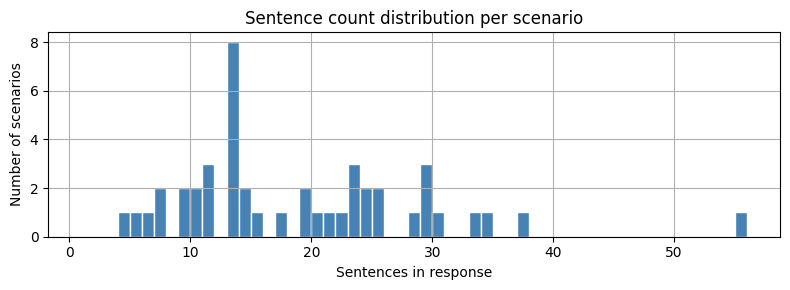

In [10]:
# ── Sentence count distribution ───────────────────────────────────────────
import matplotlib.pyplot as plt

n_sents_per_scenario = span_universe_df.groupby('scenario_id')['n_sentences'].first()
print('Sentences per scenario:')
print(n_sents_per_scenario.describe().round(1))

mean_sents = n_sents_per_scenario.mean()
if mean_sents < 3:
    print(f'\nWARNING: Mean sentences per scenario = {mean_sents:.1f} < 3.')
    print('Consider falling back to scenario-level Stage A.')
else:
    print(f'\nMean {mean_sents:.1f} sentences/scenario — span-level Stage A is feasible.')

fig, ax = plt.subplots(figsize=(8, 3))
n_sents_per_scenario.hist(bins=range(1, int(n_sents_per_scenario.max()) + 2),
                          ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Sentences in response')
ax.set_ylabel('Number of scenarios')
ax.set_title('Sentence count distribution per scenario')
plt.tight_layout()
plt.show()

In [11]:
# ── Match highlights to sentences via character overlap ────────────────────
# start_offset / end_offset in df_sel_dedup are character positions within
# original_response — the same coordinate system as sent_start / sent_end.
# Assign each highlight to the sentence with the maximum character overlap.
# Highlights that share no overlap with any sentence are flagged as unmatched.

highlight_to_span = {}  # selection_id -> span_id
unmatched = []

for _, hl in df_sel_dedup.iterrows():
    sel_id   = hl['selection_id']
    scen_id  = hl['scenario_id']
    hl_start = int(hl['start_offset']) if pd.notna(hl['start_offset']) else None
    hl_end   = int(hl['end_offset'])   if pd.notna(hl['end_offset'])   else None

    if hl_start is None or hl_end is None:
        unmatched.append(sel_id)
        continue

    candidates = span_universe_df[span_universe_df['scenario_id'] == scen_id]
    if candidates.empty:
        unmatched.append(sel_id)
        continue

    best_overlap, best_span = 0, None
    for _, sent_row in candidates.iterrows():
        overlap = char_overlap(hl_start, hl_end, sent_row['sent_start'], sent_row['sent_end'])
        if overlap > best_overlap:
            best_overlap, best_span = overlap, sent_row['span_id']

    if best_overlap > 0:
        highlight_to_span[sel_id] = best_span
    else:
        unmatched.append(sel_id)

print(f'Unique highlights:            {len(df_sel_dedup)}')
print(f'Matched (any char overlap):   {len(highlight_to_span)}')
print(f'Unmatched (no overlap found): {len(unmatched)}')
if unmatched:
    print(f'  First few unmatched: {unmatched[:5]}')

Unique highlights:            200
Matched (any char overlap):   200
Unmatched (no overlap found): 0


In [12]:
# ── n_highlighters per span ────────────────────────────────────────────────
span_highlight_counts = (
    pd.Series(highlight_to_span)
    .reset_index()
    .rename(columns={'index': 'selection_id', 0: 'span_id'})
    .groupby('span_id')
    .size()
    .rename('n_highlighters')
)
span_universe_df = span_universe_df.merge(
    span_highlight_counts.reset_index(), on='span_id', how='left'
)
span_universe_df['n_highlighters'] = span_universe_df['n_highlighters'].fillna(0).astype(int)

print('n_highlighters distribution:')
print(span_universe_df['n_highlighters'].value_counts().sort_index().to_string())
print(f'\nSpans highlighted by ≥1 parent: {(span_universe_df["n_highlighters"] > 0).sum()}')

n_highlighters distribution:
n_highlighters
0    687
1    119
2     17
3      7
4      4
5      2

Spans highlighted by ≥1 parent: 149


## 1.3  Build the Stage A panel

In [13]:
# ── Which (parent, scenario) pairs were assigned? ─────────────────────────
# Use approved moderation sessions
assignments = (
    mod[['user_id', 'scenario_id']]
    .drop_duplicates()
    .rename(columns={'user_id': 'parent_id'})
)
print(f'Assigned (parent, scenario) pairs: {len(assignments)}')
print(f'  Parents: {assignments["parent_id"].nunique()}')
print(f'  Scenarios: {assignments["scenario_id"].nunique()}')
print(f'  Scenarios per parent: {assignments.groupby("parent_id").size().describe().round(1).to_string()}')

Assigned (parent, scenario) pairs: 83
  Parents: 20
  Scenarios: 45
  Scenarios per parent: count    20.0
mean      4.2
std       0.9
min       3.0
25%       4.0
50%       4.0
75%       4.0
max       8.0


In [14]:
# ── Build panel: parent × span (for assigned scenarios only) ─────────────
# Merge assignments with span universe
panel_df = assignments.merge(span_universe_df[['span_id', 'scenario_id', 'sent_idx',
                                                'text', 'n_sentences', 'sent_start', 'sent_end']],
                             on='scenario_id', how='inner')

# Map highlight → span, then check if this parent highlighted this span
hl_span_df = df_sel[['selection_id', 'parent_id', 'scenario_id']].copy()
hl_span_df['span_id'] = hl_span_df['selection_id'].map(highlight_to_span)
hl_span_df = hl_span_df.dropna(subset=['span_id'])

highlighted_pairs = set(zip(hl_span_df['parent_id'], hl_span_df['span_id']))

panel_df['y'] = panel_df.apply(
    lambda r: 1 if (r['parent_id'], r['span_id']) in highlighted_pairs else 0,
    axis=1
)

print(f'Panel shape: {panel_df.shape}')
print(f'Positive rate (y=1): {panel_df["y"].mean():.1%} ({panel_df["y"].sum()} / {len(panel_df)})')

Panel shape: (1612, 9)
Positive rate (y=1): 10.4% (168 / 1612)


Per-parent highlight stats:


,n_rows,n_highlighted,highlight_rate
count,20.000,20.000,20.000
mean,80.600,8.400,0.114
std,34.645,4.838,0.080
min,41.000,3.000,0.040
25%,62.500,4.750,0.060
50%,73.500,7.500,0.096
75%,85.000,11.250,0.133
max,210.000,23.000,0.397


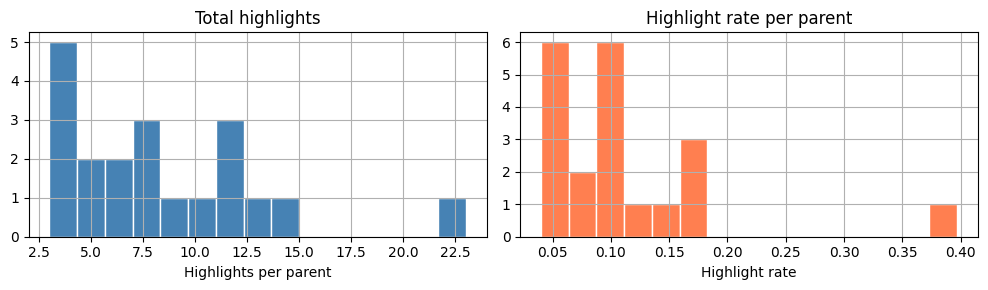

In [15]:
# ── Per-parent highlight count distribution ───────────────────────────────
per_parent = panel_df.groupby('parent_id').agg(
    n_rows=('y', 'count'),
    n_highlighted=('y', 'sum'),
    highlight_rate=('y', 'mean')
).round(3)
print('Per-parent highlight stats:')
display(per_parent.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
per_parent['n_highlighted'].hist(bins=15, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Highlights per parent')
axes[0].set_title('Total highlights')
per_parent['highlight_rate'].hist(bins=15, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_xlabel('Highlight rate')
axes[1].set_title('Highlight rate per parent')
plt.tight_layout()
plt.show()

In [ ]:
# ── Save to traces/ for downstream notebooks ──────────────────────────────
with open(os.path.join(TRACES_DIR, 'span_universe_df.pkl'), 'wb') as f:
    pickle.dump(span_universe_df, f)
with open(os.path.join(TRACES_DIR, 'panel_df.pkl'), 'wb') as f:
    pickle.dump(panel_df, f)
with open(os.path.join(TRACES_DIR, 'df_sel.pkl'), 'wb') as f:
    pickle.dump(df_sel, f)          # 267 rows — for rationale_text analysis only
with open(os.path.join(TRACES_DIR, 'df_sel_dedup.pkl'), 'wb') as f:
    pickle.dump(df_sel_dedup, f)    # 200 rows — one per unique highlight; use for modeling
with open(os.path.join(TRACES_DIR, 'highlight_to_span.pkl'), 'wb') as f:
    pickle.dump(highlight_to_span, f)

print('Saved:')
print(f'  span_universe_df:  {span_universe_df.shape}')
print(f'  panel_df:          {panel_df.shape}')
print(f'  df_sel (raw):      {df_sel.shape}  ← rationale_text analysis only')
print(f'  df_sel_dedup:      {df_sel_dedup.shape}  ← use for modeling')
print(f'  highlight_to_span: {len(highlight_to_span)} entries')